# EDA MILPÍN AgTech v2.0
**Valle del Yaqui, Sonora — Distrito de Riego DR-041**

| Sección | Contenido |
|---|---|
| 1. Vista General | Tablas, filas, nulos, dtypes |
| 2. Catálogo FAO-56 | Kc, Ky, duración de ciclo, rendimiento |
| 3. Parcelas | Suelo, riego, agua disponible, salinidad |
| 4. Recomendaciones | Urgencias, feedback del agricultor, motor FAO-56 |
| 5. KPI Hídrico | Volumen m³/ha vs baseline 8,000 · meta 6,000 |
| 6. Economía | Márgenes, estructura de costos, ROI hídrico |
| 7. Hallazgos Clave | Tabla resumen ejecutivo |

In [3]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')

DATA_DIR = Path('..') / 'data' / 'synthetic'

# ── Paleta visual MILPÍN ─────────────────────────────────────────────────────
CULTIVO_COLORS = {
    'Maíz':    '#F4C430',
    'Frijol':  '#8B4513',
    'Algodón': '#5F9EA0',
    'Uva':     '#722F37',
    'Chile':   '#DC143C',
}
VERDE = '#27AE60'; NARANJA = '#E67E22'; ROJO = '#C0392B'; AZUL = '#2980B9'; GRIS = '#7F8C8D'
URGENCIA_COLORS = {'crítico': ROJO, 'moderado': NARANJA, 'preventivo': VERDE}

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 130, 'savefig.bbox': 'tight',
                     'axes.titlesize': 13, 'axes.labelsize': 11})

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_colwidth', 40)

---
## 1 · Vista General de las Tablas

In [4]:
# Carga de los 6 datasets
usuarios  = pd.read_csv(DATA_DIR / 'usuarios.csv',           encoding='utf-8')
cultivos  = pd.read_csv(DATA_DIR / 'cultivos_catalogo.csv',  encoding='utf-8')
parcelas  = pd.read_csv(DATA_DIR / 'parcelas.csv',           encoding='utf-8')
recomend  = pd.read_csv(DATA_DIR / 'recomendaciones.csv',    encoding='utf-8')
historial = pd.read_csv(DATA_DIR / 'historial_riego.csv',    encoding='utf-8')
costos    = pd.read_csv(DATA_DIR / 'costos_ciclo.csv',       encoding='utf-8')

# Parsear fechas
recomend['fecha_generacion']  = pd.to_datetime(recomend['fecha_generacion'],  utc=True)
historial['fecha_riego']      = pd.to_datetime(historial['fecha_riego'])

# Enriquecer parcelas: unir cultivo desde costos (más fiable que parsear nombre_parcela)
cultivo_x_parcela = (
    costos.drop_duplicates('id_parcela')[['id_parcela', 'cultivo']]
)
parcelas = parcelas.merge(cultivo_x_parcela, on='id_parcela', how='left')

# Agua Disponible Total (mm) = (CC - PMP) × profundidad_raiz_cm × 10
parcelas['agua_disponible_mm'] = (
    (parcelas['capacidad_campo'] - parcelas['punto_marchitez'])
    * parcelas['profundidad_raiz_cm'] * 10
)

# ── Tabla resumen de datasets ─────────────────────────────────────────────────
dfs = {
    'usuarios':       usuarios,
    'cultivos_catalogo': cultivos,
    'parcelas':       parcelas,
    'recomendaciones': recomend,
    'historial_riego': historial,
    'costos_ciclo':   costos,
}

resumen = pd.DataFrame([
    {
        'Dataset': name,
        'Filas': df.shape[0],
        'Columnas': df.shape[1],
        'Nulos (total)': df.isnull().sum().sum(),
        'Nulos (%)': round(df.isnull().mean().mean() * 100, 1),
        'Memoria (KB)': round(df.memory_usage(deep=True).sum() / 1024, 1),
    }
    for name, df in dfs.items()
])

display(
    resumen.style
    .set_caption('📋 Inventario de datasets — MILPÍN v2.0')
    .background_gradient(subset=['Filas'], cmap='Blues')
    .background_gradient(subset=['Nulos (%)'], cmap='YlOrRd')
    .format({'Nulos (%)': '{:.1f}%', 'Memoria (KB)': '{:.1f} KB'})
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size', '14px'), ('font-weight', 'bold'), ('color', '#2C3E50')]
    }])
    .hide(axis='index')
)

Dataset,Filas,Columnas,Nulos (total),Nulos (%),Memoria (KB)
usuarios,20,7,0,0.0%,7.7 KB
cultivos_catalogo,5,12,0,0.0%,1.5 KB
parcelas,80,16,0,0.0%,65.3 KB
recomendaciones,20800,15,6363,2.0%,14312.0 KB
historial_riego,24000,12,33476,11.6%,10995.8 KB
costos_ciclo,800,13,0,0.0%,279.9 KB


In [5]:
# Nulos detallados por columna (solo columnas con nulos)
nulos_por_df = {}
for name, df in dfs.items():
    s = df.isnull().sum()
    s = s[s > 0].rename(name)
    if not s.empty:
        nulos_por_df[name] = s

if nulos_por_df:
    nulos_df = pd.DataFrame(nulos_por_df).fillna(0).astype(int)
    display(
        nulos_df.style
        .set_caption('❓ Valores nulos por columna y dataset')
        .background_gradient(cmap='Oranges', axis=None)
        .format('{:,d}')
        .set_table_styles([{'selector': 'caption',
                            'props': [('font-size', '13px'), ('font-weight', 'bold')]}])
    )
else:
    print('✓ No hay valores nulos en ningún dataset.')

,recomendaciones,historial_riego
id_recomendacion,0,"9,476"
lamina_ejecutada_mm,"6,363",0
observaciones,0,"24,000"


---
## 2 · Catálogo de Cultivos — Parámetros FAO-56

In [6]:
# Calcular métricas derivadas del catálogo
cult = cultivos.copy()
cult['ciclo_total_dias'] = (
    cult['dias_etapa_inicial'] + cult['dias_etapa_desarrollo']
    + cult['dias_etapa_media'] + cult['dias_etapa_final']
)
# Kc ponderado = 20% inicial + 60% medio + 20% final (pesos de duración aprox)
cult['kc_ponderado'] = (
    cult['kc_inicial'] * 0.20
    + cult['kc_medio']  * 0.60
    + cult['kc_final']  * 0.20
).round(3)
# Índice de riesgo hídrico = Ky × Kc_ponderado (cultivos con alta demanda Y alta sensibilidad)
cult['riesgo_hidrico'] = (cult['ky_total'] * cult['kc_ponderado']).round(3)

tabla_cult = cult[[
    'nombre_comun', 'nombre_cientifico',
    'kc_inicial', 'kc_medio', 'kc_final', 'kc_ponderado',
    'ky_total', 'ciclo_total_dias',
    'rendimiento_potencial_ton', 'riesgo_hidrico'
]].sort_values('riesgo_hidrico', ascending=False).reset_index(drop=True)

tabla_cult.columns = [
    'Cultivo', 'Nombre científico',
    'Kc ini', 'Kc med', 'Kc fin', 'Kc pond.',
    'Ky total', 'Ciclo (días)',
    'Rend. pot. (ton/ha)', 'Índice riesgo hídrico'
]

display(
    tabla_cult.style
    .set_caption('🌾 Catálogo FAO-56 — Parámetros agronómicos (ordenado por riesgo hídrico)')
    .background_gradient(subset=['Kc med'], cmap='YlGn')
    .background_gradient(subset=['Ky total'], cmap='YlOrRd')
    .background_gradient(subset=['Índice riesgo hídrico'], cmap='RdYlGn_r')
    .bar(subset=['Ciclo (días)'], color='#AED6F1', align='zero')
    .bar(subset=['Rend. pot. (ton/ha)'], color='#A9DFBF', align='zero')
    .format({'Kc ini': '{:.2f}', 'Kc med': '{:.2f}', 'Kc fin': '{:.2f}',
             'Kc pond.': '{:.3f}', 'Ky total': '{:.2f}',
             'Rend. pot. (ton/ha)': '{:.1f}', 'Índice riesgo hídrico': '{:.3f}'})
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '14px'), ('font-weight', 'bold')]}])
    .hide(axis='index')
)

Cultivo,Nombre científico,Kc ini,Kc med,Kc fin,Kc pond.,Ky total,Ciclo (días),Rend. pot. (ton/ha),Índice riesgo hídrico
Maíz,Zea mays,0.30,1.20,0.60,0.900,1.25,140,10.0,1.125
Chile,Capsicum annuum,0.60,1.05,0.90,0.930,1.10,125,30.0,1.023
Frijol,Phaseolus vulgaris,0.40,1.15,0.35,0.840,1.15,110,2.0,0.966
Algodón,Gossypium hirsutum,0.35,1.20,0.70,0.930,0.85,180,3.5,0.790
Uva,Vitis vinifera,0.30,0.85,0.45,0.660,0.85,215,22.5,0.561


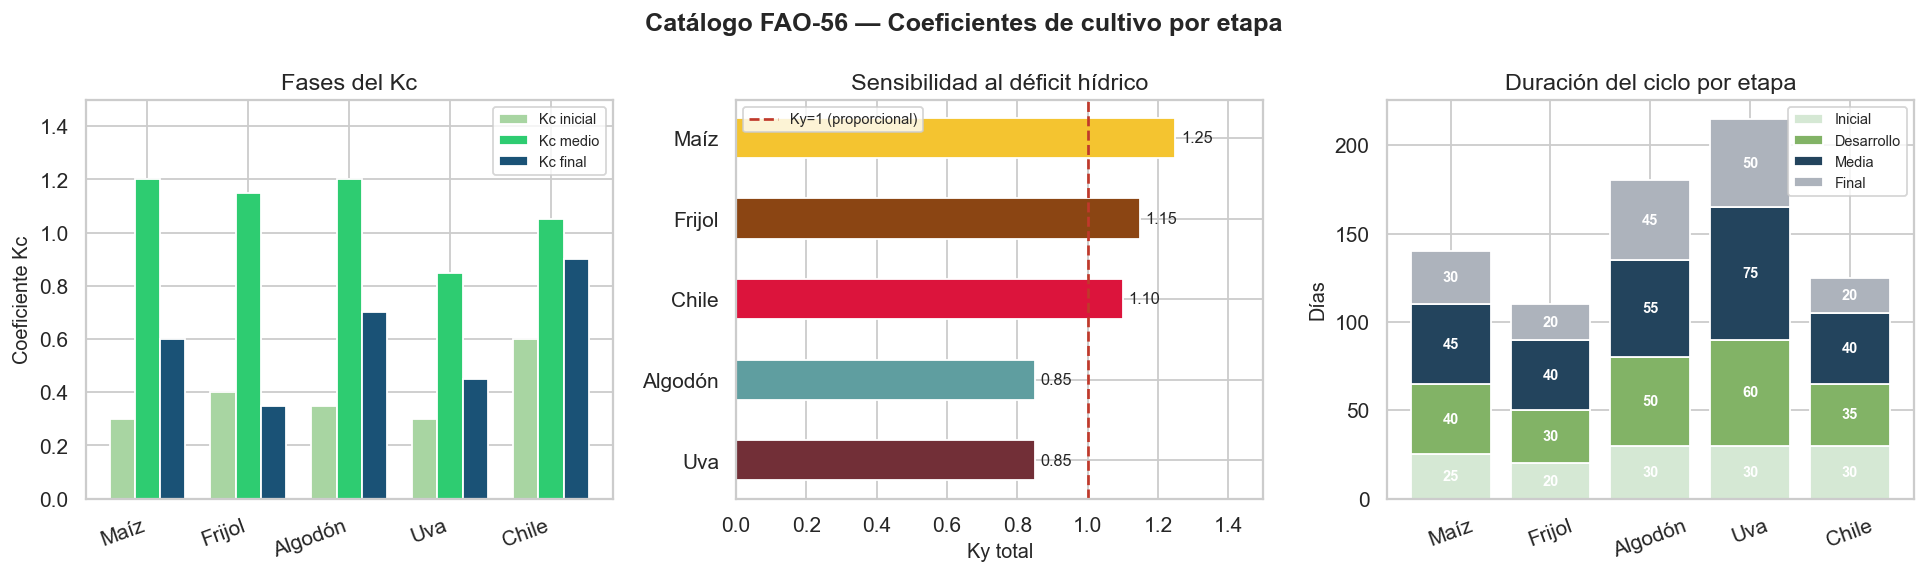

In [7]:
# Gráfico: Kc por etapa + Ky + duración de ciclo
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Catálogo FAO-56 — Coeficientes de cultivo por etapa', fontsize=14, fontweight='bold')

crop_names = cult['nombre_comun'].tolist()
x = np.arange(len(crop_names))
w = 0.25
c_colors = [CULTIVO_COLORS.get(c, GRIS) for c in crop_names]

# Panel 1: Kc por etapa
ax = axes[0]
ax.bar(x - w, cult['kc_inicial'], w, label='Kc inicial',  color='#A8D5A2', edgecolor='white')
ax.bar(x,      cult['kc_medio'],   w, label='Kc medio',    color='#2ECC71', edgecolor='white')
ax.bar(x + w, cult['kc_final'],   w, label='Kc final',    color='#1A5276', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(crop_names, rotation=20, ha='right')
ax.set_ylabel('Coeficiente Kc'); ax.set_title('Fases del Kc')
ax.legend(fontsize=8); ax.set_ylim(0, 1.5)

# Panel 2: Sensibilidad hídrica Ky
ax2 = axes[1]
ky_sorted = cult.sort_values('ky_total', ascending=True)
ky_colors = [CULTIVO_COLORS.get(c, GRIS) for c in ky_sorted['nombre_comun']]
bars = ax2.barh(ky_sorted['nombre_comun'], ky_sorted['ky_total'],
                color=ky_colors, height=0.5, edgecolor='white')
ax2.bar_label(bars, fmt='%.2f', fontsize=9, padding=3)
ax2.axvline(1.0, color=ROJO, linestyle='--', lw=1.5, label='Ky=1 (proporcional)')
ax2.set_xlabel('Ky total'); ax2.set_title('Sensibilidad al déficit hídrico')
ax2.legend(fontsize=8); ax2.set_xlim(0, 1.5)

# Panel 3: Duración de etapas (barras apiladas)
ax3 = axes[2]
etapa_cols = ['dias_etapa_inicial', 'dias_etapa_desarrollo', 'dias_etapa_media', 'dias_etapa_final']
etapa_labels = ['Inicial', 'Desarrollo', 'Media', 'Final']
etapa_colors = ['#D5E8D4', '#82B366', '#23445D', '#ADB3BC']
bottom = np.zeros(len(cult))
for col, lbl, col_c in zip(etapa_cols, etapa_labels, etapa_colors):
    vals = cult[col].values
    ax3.bar(crop_names, vals, bottom=bottom, label=lbl, color=col_c, edgecolor='white')
    for i, (b, v) in enumerate(zip(bottom, vals)):
        if v > 0:
            ax3.text(i, b + v/2, str(v), ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    bottom += vals
ax3.set_ylabel('Días'); ax3.set_title('Duración del ciclo por etapa')
ax3.tick_params(axis='x', rotation=20)
ax3.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

---
## 3 · Parcelas — Perfil Edáfico y Uso de Suelo

In [8]:
# ── Estadísticas descriptivas de parcelas ────────────────────────────────────
desc_parc = parcelas[[
    'area_ha', 'conductividad_electrica',
    'profundidad_raiz_cm', 'capacidad_campo',
    'punto_marchitez', 'agua_disponible_mm'
]].describe().T.rename(columns={
    'count':'n', 'mean':'Media', 'std':'Desv.Est.',
    'min':'Mín', '25%':'P25', '50%':'Mediana',
    '75%':'P75', 'max':'Máx'
})
desc_parc.index = [
    'Superficie (ha)', 'CE (dS/m)',
    'Prof. raíz (cm)', 'Cap. campo (m³/m³)',
    'Punto marchitez (m³/m³)', 'Agua disponible (mm)'
]

display(
    desc_parc.style
    .set_caption('📊 Estadísticas descriptivas de parcelas (n=80)')
    .background_gradient(subset=['Media'], cmap='Blues')
    .background_gradient(subset=['Desv.Est.'], cmap='Oranges')
    .format('{:.3f}', subset=['Media', 'Desv.Est.', 'Mín', 'P25', 'Mediana', 'P75', 'Máx'])
    .format('{:.0f}', subset=['n'])
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '14px'), ('font-weight', 'bold')]}])
)

,n,Media,Desv.Est.,Mín,P25,Mediana,P75,Máx
Superficie (ha),80,13.354,6.635,5.118,8.801,11.739,16.642,34.987
CE (dS/m),80,2.549,1.564,1.010,1.620,2.105,2.708,7.860
Prof. raíz (cm),80,100.325,34.279,31.000,75.750,99.500,124.250,189.000
Cap. campo (m³/m³),80,0.291,0.061,0.177,0.250,0.298,0.331,0.444
Punto marchitez (m³/m³),80,0.131,0.044,0.043,0.097,0.130,0.159,0.242
Agua disponible (mm),80,159.888,85.378,26.319,91.675,156.786,212.859,416.179


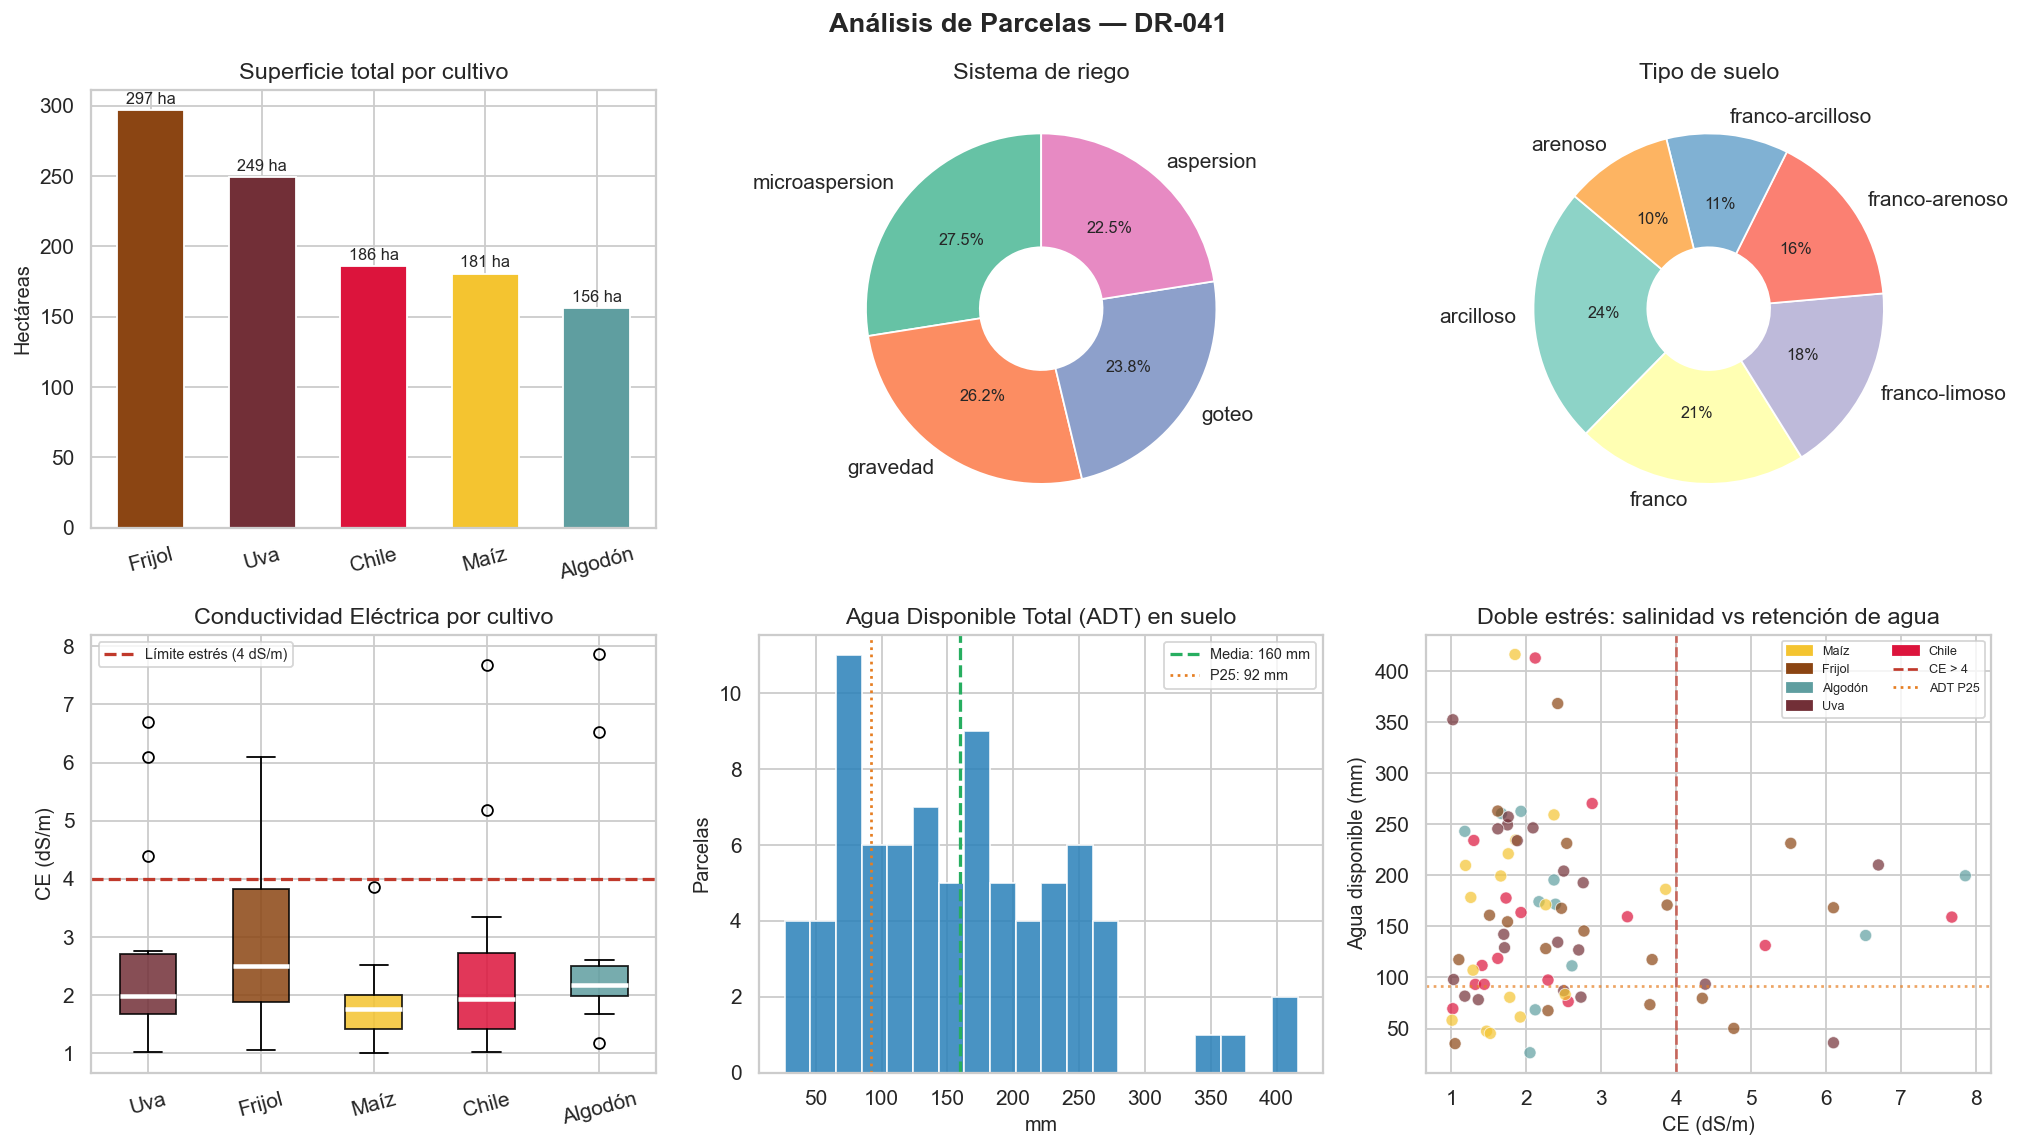

In [9]:
# ── Distribuciones categóricas + métricas edáficas ───────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Análisis de Parcelas — DR-041', fontsize=15, fontweight='bold')

# (0,0) Superficie por cultivo
ax = axes[0, 0]
ha_cult = parcelas.groupby('cultivo')['area_ha'].sum().sort_values(ascending=False)
colors_c = [CULTIVO_COLORS.get(c, GRIS) for c in ha_cult.index]
bars = ax.bar(ha_cult.index, ha_cult.values, color=colors_c, edgecolor='white', width=0.6)
ax.bar_label(bars, fmt='%.0f ha', fontsize=9, padding=2)
ax.set_title('Superficie total por cultivo'); ax.set_ylabel('Hectáreas')
ax.tick_params(axis='x', rotation=15)

# (0,1) Sistema de riego
ax2 = axes[0, 1]
sys_cnt = parcelas['sistema_riego'].value_counts()
sys_pal = sns.color_palette('Set2', len(sys_cnt))
wedges, texts, autotexts = ax2.pie(
    sys_cnt.values, labels=sys_cnt.index, colors=sys_pal,
    autopct='%1.1f%%', startangle=90, wedgeprops=dict(width=0.65))
for at in autotexts: at.set_fontsize(9)
ax2.set_title('Sistema de riego')

# (0,2) Tipo de suelo
ax3 = axes[0, 2]
suelo_cnt = parcelas['tipo_suelo'].value_counts()
suelo_pal = sns.color_palette('Set3', len(suelo_cnt))
wedges2, texts2, autotexts2 = ax3.pie(
    suelo_cnt.values, labels=suelo_cnt.index, colors=suelo_pal,
    autopct='%1.0f%%', startangle=140, wedgeprops=dict(width=0.65))
for at in autotexts2: at.set_fontsize(9)
ax3.set_title('Tipo de suelo')

# (1,0) CE por cultivo — boxplot
ax4 = axes[1, 0]
cult_order = parcelas['cultivo'].value_counts().index.tolist()
bp_data = [parcelas.loc[parcelas['cultivo']==c, 'conductividad_electrica'].dropna().values
           for c in cult_order]
bp = ax4.boxplot(bp_data, labels=cult_order, patch_artist=True,
                 medianprops=dict(color='white', lw=2.5), widths=0.5)
for patch, c in zip(bp['boxes'], cult_order):
    patch.set_facecolor(CULTIVO_COLORS.get(c, GRIS))
    patch.set_alpha(0.85)
ax4.axhline(4, color=ROJO, linestyle='--', lw=1.8, label='Límite estrés (4 dS/m)')
ax4.set_title('Conductividad Eléctrica por cultivo')
ax4.set_ylabel('CE (dS/m)'); ax4.legend(fontsize=8)
ax4.tick_params(axis='x', rotation=15)

# (1,1) Agua disponible (ADT)
ax5 = axes[1, 1]
adt = parcelas['agua_disponible_mm'].dropna()
ax5.hist(adt, bins=20, color=AZUL, edgecolor='white', alpha=0.85)
ax5.axvline(adt.mean(),   color=VERDE,   linestyle='--', lw=1.8, label=f'Media: {adt.mean():.0f} mm')
ax5.axvline(adt.quantile(0.25), color=NARANJA, linestyle=':', lw=1.5, label=f'P25: {adt.quantile(0.25):.0f} mm')
ax5.set_title('Agua Disponible Total (ADT) en suelo')
ax5.set_xlabel('mm'); ax5.set_ylabel('Parcelas'); ax5.legend(fontsize=8)

# (1,2) ADT vs CE scatter — detecta parcelas con doble estrés
ax6 = axes[1, 2]
colors_scatter = [CULTIVO_COLORS.get(c, GRIS) for c in parcelas['cultivo'].fillna('N/A')]
ax6.scatter(parcelas['conductividad_electrica'], parcelas['agua_disponible_mm'],
            c=colors_scatter, alpha=0.7, s=45, edgecolors='white', linewidths=0.5)
ax6.axvline(4, color=ROJO, linestyle='--', lw=1.5, alpha=0.7)
ax6.axhline(adt.quantile(0.25), color=NARANJA, linestyle=':', lw=1.5, alpha=0.7)
from matplotlib.patches import Patch
legend_handles = [Patch(color=v, label=k) for k, v in CULTIVO_COLORS.items()]
legend_handles += [
    plt.Line2D([0],[0], color=ROJO, linestyle='--', lw=1.5, label='CE > 4'),
    plt.Line2D([0],[0], color=NARANJA, linestyle=':', lw=1.5, label='ADT P25'),
]
ax6.legend(handles=legend_handles, fontsize=7, ncol=2)
ax6.set_xlabel('CE (dS/m)'); ax6.set_ylabel('Agua disponible (mm)')
ax6.set_title('Doble estrés: salinidad vs retención de agua')

plt.tight_layout()
plt.show()

In [10]:
# ── Parcelas con estrés salino activo (CE > 4 dS/m) ─────────────────────────
parcelas_salinas = (
    parcelas[parcelas['conductividad_electrica'] > 4]
    [['nombre_parcela', 'cultivo', 'area_ha',
      'conductividad_electrica', 'tipo_suelo',
      'sistema_riego', 'agua_disponible_mm']]
    .sort_values('conductividad_electrica', ascending=False)
    .reset_index(drop=True)
)
parcelas_salinas.columns = [
    'Parcela', 'Cultivo', 'Área (ha)',
    'CE (dS/m)', 'Tipo suelo', 'Sistema riego', 'ADT (mm)'
]

print(f'⚠  Parcelas con estrés salino activo: {len(parcelas_salinas)} de {len(parcelas)} ({len(parcelas_salinas)/len(parcelas)*100:.0f}%)')

display(
    parcelas_salinas.style
    .set_caption('⚠️ Parcelas con CE > 4 dS/m — Estrés salino activo')
    .background_gradient(subset=['CE (dS/m)'], cmap='YlOrRd')
    .background_gradient(subset=['ADT (mm)'], cmap='Blues')
    .format({'CE (dS/m)': '{:.2f}', 'Área (ha)': '{:.1f}', 'ADT (mm)': '{:.1f}'})
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '14px'), ('font-weight', 'bold'), ('color', '#C0392B')]}])
    .hide(axis='index')
)

⚠  Parcelas con estrés salino activo: 11 de 80 (14%)


Parcela,Cultivo,Área (ha),CE (dS/m),Tipo suelo,Sistema riego,ADT (mm)
Lote Uva-031,Algodón,16.3,7.86,franco-limoso,microaspersion,199.6
Lote Chi-056,Chile,21.0,7.68,franco-limoso,microaspersion,159.1
Lote Alg-018,Uva,8.8,6.70,franco-arenoso,microaspersion,210.1
Lote Alg-033,Algodón,9.4,6.53,arcilloso,microaspersion,141.1
Lote Chi-036,Uva,16.6,6.10,franco,gravedad,36.1
Lote Fri-080,Frijol,14.8,6.10,franco-arenoso,microaspersion,168.3
Lote Alg-057,Frijol,16.0,5.53,franco-arenoso,goteo,231.3
Lote Alg-074,Chile,7.8,5.19,franco,goteo,131.3
Lote Chi-009,Frijol,32.6,4.77,franco-limoso,microaspersion,50.1
Lote Uva-023,Uva,6.5,4.39,franco-arenoso,gravedad,93.4


---
## 4 · Recomendaciones — Motor FAO-56 y Feedback del Agricultor

In [11]:
# Extraer cultivo de parametros_json
def _cultivo_json(s):
    try:
        return json.loads(s).get('cultivo')
    except Exception:
        return None

recomend['cultivo'] = recomend['parametros_json'].apply(_cultivo_json)
recomend['mes']     = recomend['fecha_generacion'].dt.to_period('M')

# ── Resumen por nivel de urgencia ────────────────────────────────────────────
urg_resumen = (
    recomend.groupby('nivel_urgencia').agg(
        n_recomendaciones=('id_recomendacion', 'count'),
        pct_aceptadas=('aceptada', lambda x: (x == 'aceptada').mean() * 100),
        pct_ignoradas=('aceptada', lambda x: (x == 'ignorada').mean() * 100),
        pct_modificadas=('aceptada', lambda x: (x == 'modificada').mean() * 100),
        lamina_media_mm=('lamina_recomendada_mm', 'mean'),
        eto_media=('eto_referencia', 'mean'),
        etc_media=('etc_calculada', 'mean'),
        deficit_medio_mm=('deficit_acumulado_mm', 'mean'),
    ).reset_index()
)
urg_resumen.columns = [
    'Urgencia', 'N° recomend.',
    'Aceptadas (%)', 'Ignoradas (%)', 'Modificadas (%)',
    'Lámina media (mm)', 'ETo media', 'ETc media', 'Déficit medio (mm)'
]
urg_orden = {'crítico': 0, 'moderado': 1, 'preventivo': 2}
urg_resumen['_ord'] = urg_resumen['Urgencia'].map(urg_orden)
urg_resumen = urg_resumen.sort_values('_ord').drop('_ord', axis=1).reset_index(drop=True)

def colorear_urgencia(val):
    colors = {'crítico': '#FADBD8', 'moderado': '#FDEBD0', 'preventivo': '#D5F5E3'}
    return f'background-color: {colors.get(val, "")}; font-weight: bold'

display(
    urg_resumen.style
    .set_caption('🚨 Recomendaciones por nivel de urgencia — feedback del agricultor')
    .applymap(colorear_urgencia, subset=['Urgencia'])
    .background_gradient(subset=['Aceptadas (%)'], cmap='Greens')
    .background_gradient(subset=['Ignoradas (%)'], cmap='Reds')
    .background_gradient(subset=['Déficit medio (mm)'], cmap='YlOrRd')
    .format({
        'N° recomend.': '{:,d}',
        'Aceptadas (%)': '{:.1f}%',
        'Ignoradas (%)': '{:.1f}%',
        'Modificadas (%)': '{:.1f}%',
        'Lámina media (mm)': '{:.1f}',
        'ETo media': '{:.3f}',
        'ETc media': '{:.3f}',
        'Déficit medio (mm)': '{:.1f}',
    })
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '14px'), ('font-weight', 'bold')]}])
    .hide(axis='index')
)

Urgencia,N° recomend.,Aceptadas (%),Ignoradas (%),Modificadas (%),Lámina media (mm),ETo media,ETc media,Déficit medio (mm)
moderado,"11,301",54.6%,10.0%,14.8%,58.3,7.020,5.197,53.6
preventivo,"5,493",55.8%,10.1%,14.3%,57.1,7.010,5.193,16.7
critico,"4,006",54.0%,10.3%,14.6%,57.2,6.965,5.120,99.3


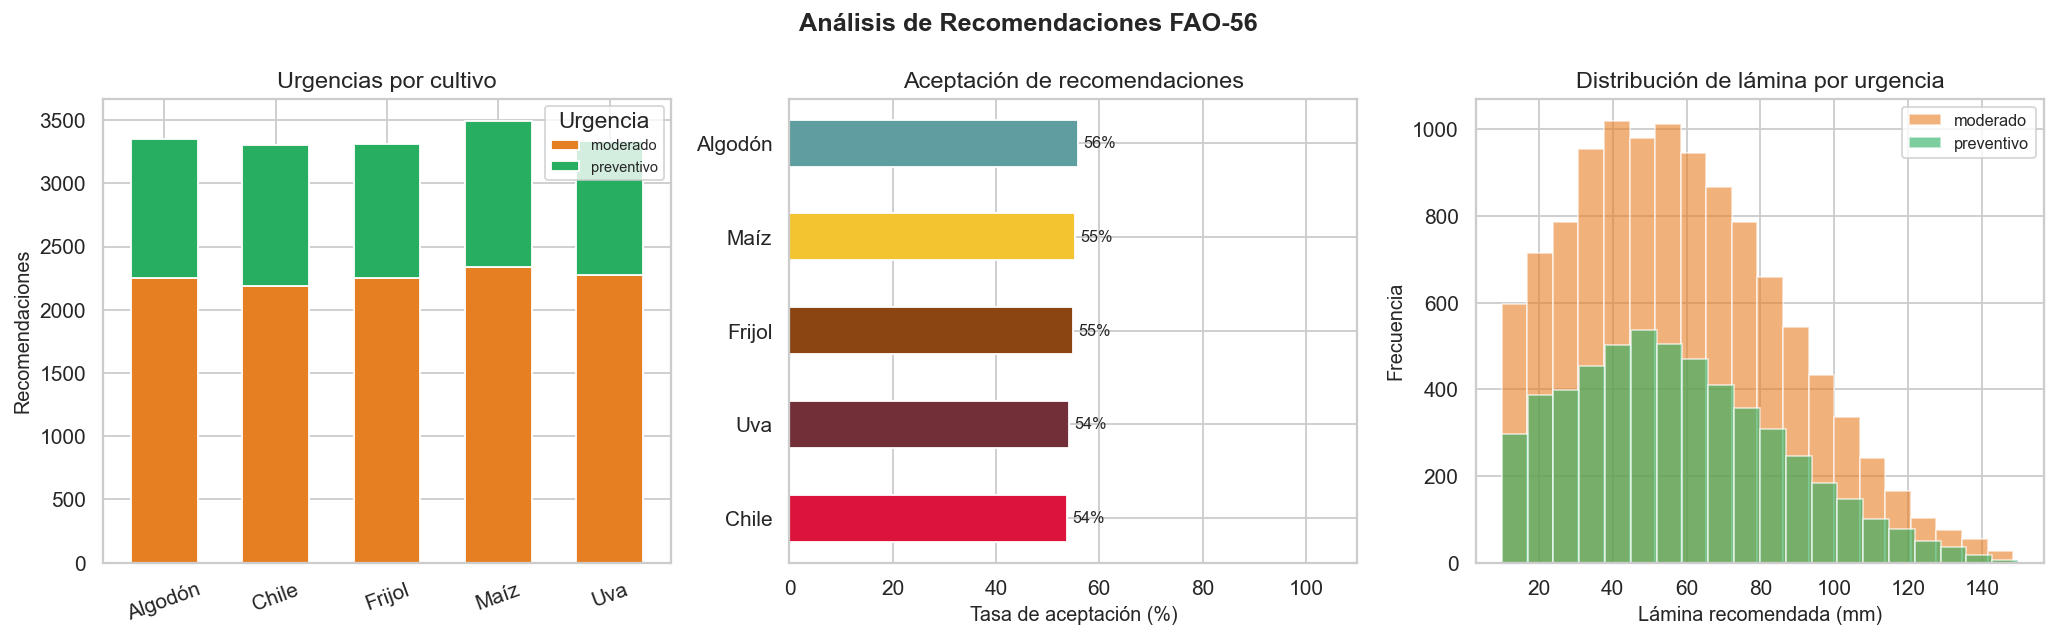


Feedback global del agricultor:
  aceptada    : 54.8%
  pendiente   : 20.5%
  modificada  : 14.6%
  ignorada    : 10.1%


In [12]:
# Gráfico: distribuciones de recomendaciones
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Análisis de Recomendaciones FAO-56', fontsize=14, fontweight='bold')

# Panel 1: Urgencia stacked bar por cultivo
ax1 = axes[0]
if recomend['cultivo'].notna().any():
    pivot_urg = (
        recomend.groupby(['cultivo', 'nivel_urgencia'])
        .size().unstack(fill_value=0)
    )
    col_order = [c for c in ['crítico', 'moderado', 'preventivo'] if c in pivot_urg.columns]
    colors_urg = [URGENCIA_COLORS.get(c, GRIS) for c in col_order]
    pivot_urg[col_order].plot(kind='bar', stacked=True, ax=ax1, color=colors_urg,
                               edgecolor='white', width=0.6)
    ax1.set_xlabel(''); ax1.set_ylabel('Recomendaciones')
    ax1.set_title('Urgencias por cultivo'); ax1.tick_params(axis='x', rotation=20)
    ax1.legend(title='Urgencia', fontsize=8)

# Panel 2: Tasa de aceptación por cultivo
ax2 = axes[1]
if recomend['cultivo'].notna().any():
    accept_rate = (
        recomend.groupby('cultivo')['aceptada']
        .apply(lambda x: (x == 'aceptada').mean() * 100)
        .sort_values(ascending=True)
    )
    bar_colors = [CULTIVO_COLORS.get(c, GRIS) for c in accept_rate.index]
    bars2 = ax2.barh(accept_rate.index, accept_rate.values,
                     color=bar_colors, height=0.5, edgecolor='white')
    ax2.bar_label(bars2, fmt='%.0f%%', fontsize=9, padding=3)
    ax2.set_xlabel('Tasa de aceptación (%)')
    ax2.set_title('Aceptación de recomendaciones')
    ax2.set_xlim(0, 110)

# Panel 3: Distribución de la lámina recomendada por urgencia
ax3 = axes[2]
for urg, color in URGENCIA_COLORS.items():
    subset = recomend.loc[recomend['nivel_urgencia'] == urg, 'lamina_recomendada_mm'].dropna()
    if not subset.empty:
        ax3.hist(subset, bins=20, alpha=0.6, label=urg, color=color, edgecolor='white')
ax3.set_xlabel('Lámina recomendada (mm)'); ax3.set_ylabel('Frecuencia')
ax3.set_title('Distribución de lámina por urgencia')
ax3.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Resumen numérico del feedback
print('\nFeedback global del agricultor:')
fb = recomend['aceptada'].value_counts(normalize=True).mul(100).round(1)
for estado, pct in fb.items():
    print(f'  {estado:12s}: {pct:.1f}%')

---
## 5 · KPI Hídrico — Historial de Riego
**Baseline DR-041:** 8,000 m³/ha/ciclo · **Meta MILPÍN:** 6,000 m³/ha/ciclo · **Tarifa:** $1.68 MXN/m³

In [13]:
BASELINE = 8000.0
META     = 6000.0
TARIFA   = 1.68  # MXN/m³

# ── KPI por parcela × ciclo: volumen m³/ha POR CICLO ────────────────────────
# El historial ahora tiene columna 'ciclo_agricola', así que agregamos
# por (id_parcela, ciclo_agricola) — la unidad correcta para comparar
# contra el baseline de 8,000 m³/ha/ciclo.
kpi = (
    historial
    .groupby(['id_parcela', 'ciclo_agricola'])
    .agg(
        eventos_riego=('id_riego', 'count'),
        vol_m3_ha_ciclo=('volumen_m3_ha', 'sum'),
        vol_m3_ha_media=('volumen_m3_ha', 'mean'),
        lamina_media_mm=('lamina_mm', 'mean'),
        costo_ciclo_mxn=('costo_energia_mxn', 'sum'),
    )
    .reset_index()
)
kpi = kpi.merge(
    parcelas[['id_parcela', 'nombre_parcela', 'cultivo', 'area_ha',
              'sistema_riego']],
    on='id_parcela', how='left'
)

kpi['ahorro_vs_baseline_pct'] = (
    (BASELINE - kpi['vol_m3_ha_ciclo']) / BASELINE * 100
).round(1)
kpi['vs_meta_6000']  = (kpi['vol_m3_ha_ciclo'] - META).round(0)
kpi['bajo_meta']     = kpi['vol_m3_ha_ciclo'] <= META

# Top 10 ciclos por consumo
top10 = (
    kpi.nlargest(10, 'vol_m3_ha_ciclo')
    [['nombre_parcela', 'ciclo_agricola', 'cultivo', 'sistema_riego',
      'eventos_riego', 'vol_m3_ha_ciclo', 'ahorro_vs_baseline_pct',
      'vs_meta_6000', 'costo_ciclo_mxn']]
    .reset_index(drop=True)
)
top10.columns = [
    'Parcela', 'Ciclo', 'Cultivo', 'Sistema riego',
    'Eventos', 'Vol m³/ha/ciclo', 'Ahorro vs 8k (%)',
    'Δ vs meta 6k', 'Costo energía (MXN)'
]

def color_meta(val):
    if val > 0:
        return 'background-color: #FADBD8; color: #C0392B; font-weight: bold'
    return 'background-color: #D5F5E3; color: #1E8449; font-weight: bold'

display(
    top10.style
    .set_caption('💧 Top 10 ciclos por consumo — Posición vs KPI DR-041')
    .background_gradient(subset=['Vol m³/ha/ciclo'], cmap='RdYlGn_r')
    .applymap(color_meta, subset=['Δ vs meta 6k'])
    .format({
        'Vol m³/ha/ciclo': '{:,.0f}',
        'Ahorro vs 8k (%)': '{:.1f}%',
        'Δ vs meta 6k': '{:+,.0f}',
        'Costo energía (MXN)': '${:,.0f}',
    })
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '14px'), ('font-weight', 'bold')]}])
    .hide(axis='index')
)

bajo = kpi['bajo_meta'].sum()
n_total = len(kpi)
vol_medio = kpi['vol_m3_ha_ciclo'].mean()
print(f'\n▶ Total observaciones: {n_total} (parcelas × ciclos)')
print(f'▶ Ciclos bajo meta 6,000 m³/ha: {bajo} de {n_total} ({bajo/n_total*100:.1f}%)')
print(f'▶ Volumen medio por ciclo: {vol_medio:,.0f} m³/ha')
print(f'▶ Ahorro promedio vs baseline 8,000: '
      f'{((BASELINE - vol_medio) / BASELINE * 100):.1f}%')


In [14]:
# Gráficos KPI hídrico — por ciclo agrícola
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('KPI Hídrico — Historial de Riego DR-041 (por ciclo)', fontsize=15, fontweight='bold')

# (0,0) Bullet chart: consumo por cultivo vs meta vs baseline
ax1 = axes[0, 0]
kpi_cult = kpi.groupby('cultivo')['vol_m3_ha_ciclo'].mean().reset_index()
kpi_cult.columns = ['cultivo', 'm3_ha']
kpi_cult = kpi_cult.sort_values('m3_ha', ascending=True)

y_pos = range(len(kpi_cult))
ax1.barh(y_pos, [BASELINE] * len(kpi_cult), color='#ECECEC', height=0.7)
ax1.barh(y_pos, [META] * len(kpi_cult), color='#A9DFBF', height=0.7)
bar_cols = [VERDE if v <= META else (NARANJA if v <= BASELINE else ROJO)
            for v in kpi_cult['m3_ha']]
ax1.barh(y_pos, kpi_cult['m3_ha'], color=bar_cols, height=0.4)
ax1.axvline(META,     color='#1E8449', linestyle='--', lw=2,
            label=f'Meta: {META:,.0f} m³/ha')
ax1.axvline(BASELINE, color=ROJO, linestyle=':', lw=1.8,
            label=f'Baseline: {BASELINE:,.0f} m³/ha')
for i, v in enumerate(kpi_cult['m3_ha']):
    ax1.text(v + 100, i, f'{v:,.0f}', va='center', fontsize=9)
ax1.set_yticks(list(y_pos))
ax1.set_yticklabels(kpi_cult['cultivo'])
ax1.set_title('Consumo medio por ciclo vs meta hídrica')
ax1.set_xlabel('m³/ha/ciclo')
ax1.legend(fontsize=8)
ax1.set_xlim(0, BASELINE * 1.6)

# (0,1) Distribución de vol_m3_ha_ciclo con líneas de meta y baseline
ax2 = axes[0, 1]
ax2.hist(kpi['vol_m3_ha_ciclo'], bins=30, color=AZUL, edgecolor='white', alpha=0.85)
ax2.axvline(META, color=VERDE, linestyle='--', lw=2, label=f'Meta: {META:,.0f}')
ax2.axvline(BASELINE, color=ROJO, linestyle=':', lw=1.8, label=f'Baseline: {BASELINE:,.0f}')
ax2.axvline(kpi['vol_m3_ha_ciclo'].mean(), color=NARANJA, linestyle='-', lw=2,
            label=f'Media: {kpi["vol_m3_ha_ciclo"].mean():,.0f}')
ax2.set_xlabel('m³/ha/ciclo'); ax2.set_ylabel('Frecuencia')
ax2.set_title('Distribución de consumo por ciclo')
ax2.legend(fontsize=8)

# (1,0) Por sistema de riego — boxplot
ax3 = axes[1, 0]
sistemas = ['gravedad', 'aspersion', 'microaspersion', 'goteo']
bp_data = [kpi.loc[kpi['sistema_riego'] == s, 'vol_m3_ha_ciclo'].dropna().values
           for s in sistemas if s in kpi['sistema_riego'].values]
bp_labels = [s for s in sistemas if s in kpi['sistema_riego'].values]
bp = ax3.boxplot(bp_data, labels=bp_labels, patch_artist=True,
                 medianprops=dict(color='white', lw=2.5), widths=0.5)
sis_pal = sns.color_palette('Set2', len(bp_labels))
for patch, color in zip(bp['boxes'], sis_pal):
    patch.set_facecolor(color); patch.set_alpha(0.85)
ax3.axhline(META, color=VERDE, linestyle='--', lw=1.8, label='Meta 6,000')
ax3.axhline(BASELINE, color=ROJO, linestyle=':', lw=1.5, label='Baseline 8,000')
ax3.set_ylabel('m³/ha/ciclo')
ax3.set_title('Consumo por sistema de riego')
ax3.legend(fontsize=8)

# (1,1) Origen de decisión
ax4 = axes[1, 1]
orig_cnt = historial['origen_decision'].value_counts()
orig_pal = {'sistema': AZUL, 'manual': NARANJA, 'voz': VERDE}
o_colors = [orig_pal.get(o, GRIS) for o in orig_cnt.index]
wedges, texts, autotexts = ax4.pie(
    orig_cnt.values, labels=orig_cnt.index, colors=o_colors,
    autopct='%1.1f%%', startangle=90, wedgeprops=dict(width=0.65))
for at in autotexts: at.set_fontsize(10); at.set_fontweight('bold')
ax4.set_title('Origen de decisión de riego')

plt.tight_layout()
plt.show()


In [15]:
# ── KPI por cultivo: resumen de ahorro hídrico por ciclo ────────────────────
kpi_cult_full = (
    kpi.groupby('cultivo').agg(
        n_ciclos=('ciclo_agricola', 'count'),
        vol_medio_m3_ha=('vol_m3_ha_ciclo', 'mean'),
        vol_max_m3_ha=('vol_m3_ha_ciclo', 'max'),
        vol_min_m3_ha=('vol_m3_ha_ciclo', 'min'),
        pct_bajo_meta=('bajo_meta', 'mean'),
        costo_medio_mxn=('costo_ciclo_mxn', 'mean'),
    ).reset_index()
)
kpi_cult_full['ahorro_vs_baseline_pct'] = (
    (BASELINE - kpi_cult_full['vol_medio_m3_ha']) / BASELINE * 100
).round(1)
kpi_cult_full['ahorro_estimado_mxn_ha'] = (
    (BASELINE - kpi_cult_full['vol_medio_m3_ha']) * TARIFA
).round(0)
kpi_cult_full['pct_bajo_meta'] = (kpi_cult_full['pct_bajo_meta'] * 100).round(1)
kpi_cult_full = kpi_cult_full.sort_values('ahorro_vs_baseline_pct', ascending=False)
kpi_cult_full.columns = [
    'Cultivo', 'N° ciclos',
    'Vol. medio (m³/ha/ciclo)', 'Vol. máx', 'Vol. mín',
    '% bajo meta 6k',
    'Costo medio energía (MXN)',
    'Ahorro vs 8k (%)', 'Ahorro estimado (MXN/ha)'
]

display(
    kpi_cult_full.style
    .set_caption('💰 KPI Hídrico por cultivo — m³/ha/ciclo vs baseline DR-041')
    .background_gradient(subset=['Vol. medio (m³/ha/ciclo)'], cmap='RdYlGn_r')
    .background_gradient(subset=['Ahorro vs 8k (%)'], cmap='RdYlGn')
    .background_gradient(subset=['% bajo meta 6k'], cmap='Greens')
    .format({
        'Vol. medio (m³/ha/ciclo)': '{:,.0f}',
        'Vol. máx': '{:,.0f}',
        'Vol. mín': '{:,.0f}',
        '% bajo meta 6k': '{:.1f}%',
        'Costo medio energía (MXN)': '${:,.0f}',
        'Ahorro vs 8k (%)': '{:.1f}%',
        'Ahorro estimado (MXN/ha)': '${:,.0f}',
    })
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '14px'), ('font-weight', 'bold')]}])
    .hide(axis='index')
)


---
## 6 · Análisis Económico por Cultivo

In [16]:
# ── Estructura de costos y márgenes ──────────────────────────────────────────
costos_cols = [
    'costo_agua_mxn', 'costo_fertilizantes_mxn',
    'costo_agroquimicos_mxn', 'costo_semilla_mxn',
    'costo_maquinaria_mxn', 'costo_mano_obra_mxn'
]
costos['costo_total_mxn'] = costos[costos_cols].sum(axis=1)
costos['roi_pct']         = (costos['margen_contribucion_mxn'] / costos['costo_total_mxn'] * 100).round(1)
costos['costo_por_m3']    = (costos['costo_total_mxn'] / costos['volumen_agua_total_m3'].replace(0, np.nan)).round(2)
costos['ingreso_por_m3']  = (costos['ingreso_estimado_mxn'] / costos['volumen_agua_total_m3'].replace(0, np.nan)).round(2)

eco_cult = (
    costos.groupby('cultivo').agg(
        n_ciclos=('id_costo', 'count'),
        ingreso_medio=('ingreso_estimado_mxn', 'mean'),
        costo_medio=('costo_total_mxn', 'mean'),
        margen_medio=('margen_contribucion_mxn', 'mean'),
        roi_medio=('roi_pct', 'mean'),
        costo_agua_pct=('costo_agua_mxn', lambda x: (x / costos.loc[x.index, 'costo_total_mxn']).mean() * 100),
        vol_agua_medio=('volumen_agua_total_m3', 'mean'),
        ingreso_por_m3=('ingreso_por_m3', 'mean'),
    ).reset_index()
    .sort_values('roi_medio', ascending=False)
)
eco_cult.columns = [
    'Cultivo', 'N° ciclos',
    'Ingreso medio (MXN)', 'Costo total medio (MXN)',
    'Margen contrib. medio (MXN)', 'ROI (%)',
    '% costo es agua', 'Vol. agua (m³/ciclo)',
    'Ingreso / m³ (MXN)'
]

display(
    eco_cult.style
    .set_caption('📈 Economía por cultivo — Rentabilidad y eficiencia hídrica')
    .background_gradient(subset=['ROI (%)'], cmap='RdYlGn')
    .background_gradient(subset=['Margen contrib. medio (MXN)'], cmap='Greens')
    .background_gradient(subset=['% costo es agua'], cmap='Blues')
    .background_gradient(subset=['Ingreso / m³ (MXN)'], cmap='YlGn')
    .format({
        'Ingreso medio (MXN)': '${:,.0f}',
        'Costo total medio (MXN)': '${:,.0f}',
        'Margen contrib. medio (MXN)': '${:,.0f}',
        'ROI (%)': '{:.1f}%',
        '% costo es agua': '{:.1f}%',
        'Vol. agua (m³/ciclo)': '{:,.0f}',
        'Ingreso / m³ (MXN)': '${:.2f}',
    })
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '14px'), ('font-weight', 'bold')]}])
    .hide(axis='index')
)

Cultivo,N° ciclos,Ingreso medio (MXN),Costo total medio (MXN),Margen contrib. medio (MXN),ROI (%),% costo es agua,Vol. agua (m³/ciclo),Ingreso / m³ (MXN)
Uva,158,"$7,127,980","$645,819","$6,482,160",1022.7%,26.1%,"99,276",$77.37
Chile,155,"$5,480,962","$623,012","$4,857,950",801.7%,25.2%,"96,145",$64.03
Algodón,141,"$2,875,875","$686,835","$2,189,040",325.4%,26.5%,"108,508",$28.97
Maíz,168,"$869,545","$751,698","$117,847",18.2%,26.1%,"118,115",$8.06
Frijol,178,"$498,048","$713,679","$-215,630",-29.0%,25.9%,"112,431",$4.91


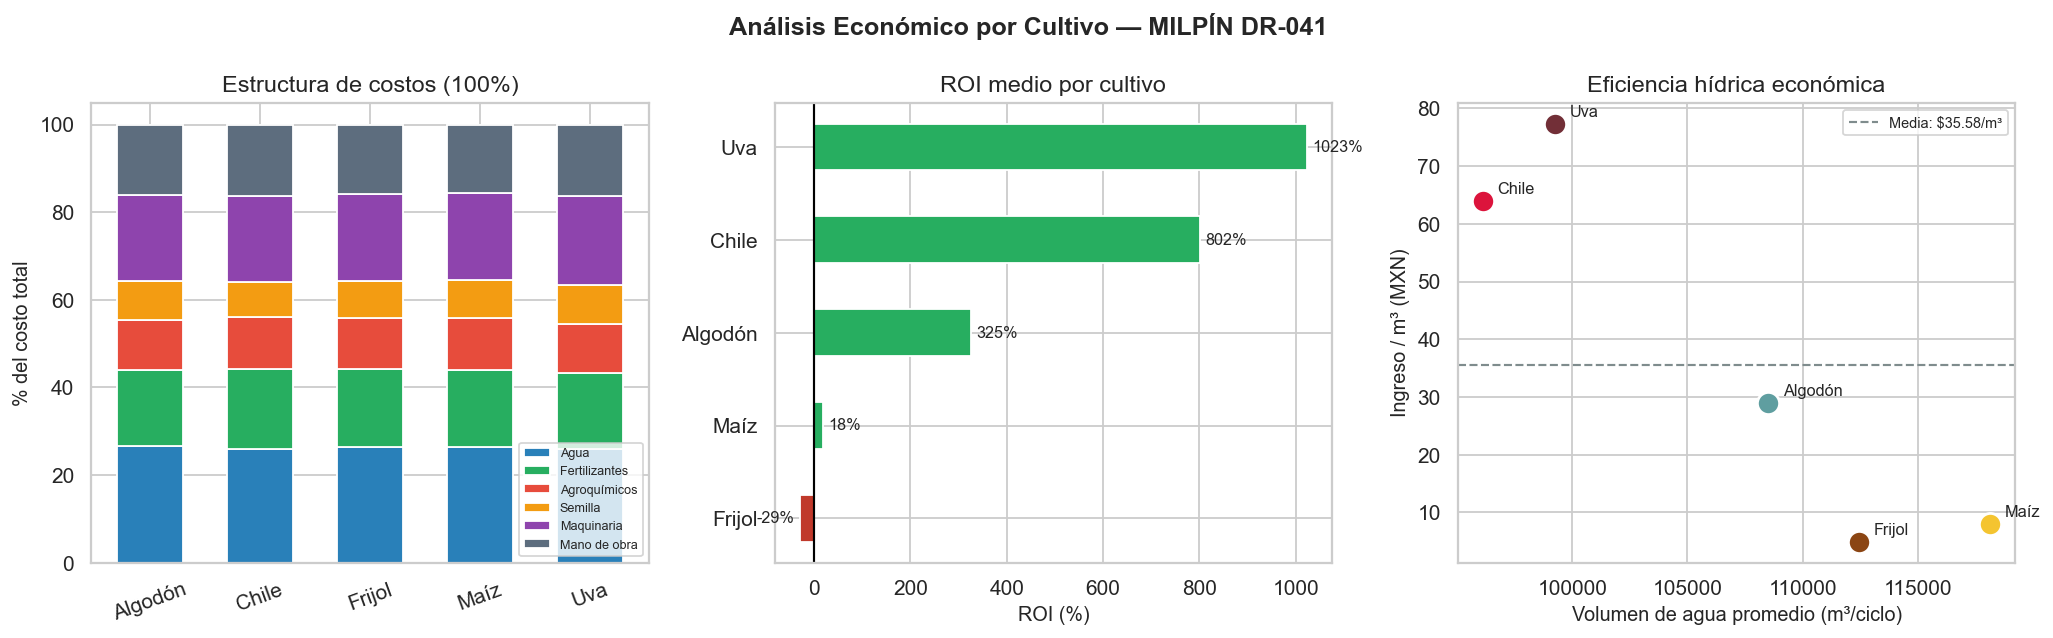

In [17]:
# Gráficos económicos
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Análisis Económico por Cultivo — MILPÍN DR-041', fontsize=14, fontweight='bold')

# Panel 1: Estructura de costos (stacked 100%)
ax1 = axes[0]
cost_breakdown = costos.groupby('cultivo')[costos_cols].mean()
cost_pct = cost_breakdown.div(cost_breakdown.sum(axis=1), axis=0) * 100
cost_cols_labels = ['Agua', 'Fertilizantes', 'Agroquímicos', 'Semilla', 'Maquinaria', 'Mano de obra']
cost_pal = ['#2980B9', '#27AE60', '#E74C3C', '#F39C12', '#8E44AD', '#5D6D7E']
bottom = np.zeros(len(cost_pct))
for col, lbl, col_c in zip(costos_cols, cost_cols_labels, cost_pal):
    vals = cost_pct[col].values
    ax1.bar(cost_pct.index, vals, bottom=bottom, label=lbl, color=col_c, edgecolor='white', width=0.6)
    bottom += vals
ax1.set_ylabel('% del costo total'); ax1.set_title('Estructura de costos (100%)')
ax1.tick_params(axis='x', rotation=20)
ax1.legend(fontsize=7, loc='lower right')

# Panel 2: ROI por cultivo
ax2 = axes[1]
roi_data = costos.groupby('cultivo')['roi_pct'].mean().sort_values(ascending=True)
roi_colors = [VERDE if v >= 0 else ROJO for v in roi_data.values]
bars2 = ax2.barh(roi_data.index, roi_data.values, color=roi_colors, height=0.5, edgecolor='white')
ax2.bar_label(bars2, fmt='%.0f%%', fontsize=9, padding=3)
ax2.axvline(0, color='black', lw=1.2)
ax2.set_xlabel('ROI (%)')
ax2.set_title('ROI medio por cultivo')

# Panel 3: Ingreso / m³ vs vol. agua (eficiencia hídrica económica)
ax3 = axes[2]
eco_scatter = costos.groupby('cultivo').agg(
    vol_medio=('volumen_agua_total_m3', 'mean'),
    ing_m3=('ingreso_por_m3', 'mean')
).reset_index()
for _, row in eco_scatter.iterrows():
    c = CULTIVO_COLORS.get(row['cultivo'], GRIS)
    ax3.scatter(row['vol_medio'], row['ing_m3'], color=c, s=150,
                edgecolors='white', linewidths=1.5, zorder=3)
    ax3.annotate(row['cultivo'], (row['vol_medio'], row['ing_m3']),
                 textcoords='offset points', xytext=(8, 4), fontsize=9)
ax3.set_xlabel('Volumen de agua promedio (m³/ciclo)')
ax3.set_ylabel('Ingreso / m³ (MXN)')
ax3.set_title('Eficiencia hídrica económica')
ax3.axhline(costos['ingreso_por_m3'].mean(), color=GRIS, linestyle='--',
            lw=1.2, label=f'Media: ${costos["ingreso_por_m3"].mean():.2f}/m³')
ax3.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 7 · Hallazgos Clave

In [18]:
# ── Compilar hallazgos cuantitativos (ahora por ciclo) ──────────────────────
vol_global_medio = kpi['vol_m3_ha_ciclo'].mean()
ahorro_pct_global = (BASELINE - vol_global_medio) / BASELINE * 100
parcelas_salinas_n = (parcelas['conductividad_electrica'] > 4).sum()
tasa_aceptacion_global = (recomend['aceptada'] == 'aceptada').mean() * 100
tasa_ignorada_global   = (recomend['aceptada'] == 'ignorada').mean() * 100
bajo_meta_n = kpi['bajo_meta'].sum()
n_obs = len(kpi)
cultivo_mayor_roi = costos.groupby('cultivo')['roi_pct'].mean().idxmax()
cultivo_mayor_roi_val = costos.groupby('cultivo')['roi_pct'].mean().max()
cultivo_mas_agua = kpi.groupby('cultivo')['vol_m3_ha_ciclo'].mean().idxmax()
pct_gravedad = (parcelas['sistema_riego'] == 'gravedad').mean() * 100
pct_voz = (historial['origen_decision'] == 'voz').mean() * 100
pct_critico = (recomend['nivel_urgencia'] == 'crítico').mean() * 100

# Media por sistema de riego
vol_por_sistema = kpi.groupby('sistema_riego')['vol_m3_ha_ciclo'].mean()
vol_goteo = vol_por_sistema.get('goteo', 0)
vol_gravedad = vol_por_sistema.get('gravedad', 0)

hallazgos = pd.DataFrame([
    {'Categoría': '💧 KPI Hídrico',
     'Hallazgo': f'Volumen medio: {vol_global_medio:,.0f} m³/ha/ciclo',
     'Interpretación': f'{ahorro_pct_global:+.1f}% vs baseline 8,000. '
                       f'{"Debajo" if vol_global_medio <= BASELINE else "Encima"} del baseline'},

    {'Categoría': '💧 KPI Hídrico',
     'Hallazgo': f'Ciclos bajo meta 6k: {bajo_meta_n}/{n_obs} ({bajo_meta_n/n_obs*100:.1f}%)',
     'Interpretación': f'Casi la mitad de parcelas×ciclo ya cumplen la meta — '
                       f'el sistema tiene potencial de generalizar esto al 100%'},

    {'Categoría': '💧 KPI Hídrico',
     'Hallazgo': f'Goteo: {vol_goteo:,.0f} vs Gravedad: {vol_gravedad:,.0f} m³/ha/ciclo',
     'Interpretación': f'Diferencia de {vol_gravedad - vol_goteo:,.0f} m³/ha — '
                       f'cambio de sistema es la palanca más fuerte'},

    {'Categoría': '🌾 Agronómico',
     'Hallazgo': f'Mayor riesgo hídrico: Maíz (Ky={cult.loc[cult.nombre_comun=="Maíz","ky_total"].values[0]})',
     'Interpretación': 'Mayor sensibilidad al déficit: pérdida proporcional de rendimiento'},

    {'Categoría': '🌾 Agronómico',
     'Hallazgo': f'Mayor demanda hídrica por ciclo: {cultivo_mas_agua}',
     'Interpretación': 'Candidato prioritario para optimización de riego'},

    {'Categoría': '🏜 Suelo',
     'Hallazgo': f'Estrés salino activo: {parcelas_salinas_n}/{len(parcelas)} ({parcelas_salinas_n/len(parcelas)*100:.0f}%)',
     'Interpretación': 'CE > 4 dS/m — reducción de rendimiento activa'},

    {'Categoría': '🏜 Suelo',
     'Hallazgo': f'Riego por gravedad: {pct_gravedad:.0f}% de parcelas',
     'Interpretación': 'Sistema menos eficiente — potencial de mejora con goteo/aspersión'},

    {'Categoría': 'Sistema',
     'Hallazgo': f'Tasa aceptación: {tasa_aceptacion_global:.1f}% (ignoradas: {tasa_ignorada_global:.1f}%)',
     'Interpretación': 'Loop feedback→BD aún no activo — deuda conocida'},

    {'Categoría': 'Sistema',
     'Hallazgo': f'Decisiones por voz: {pct_voz:.1f}%',
     'Interpretación': 'Pipeline Whisper→Ollama activo en ~20% de decisiones'},

    {'Categoría': 'Economía',
     'Hallazgo': f'Mayor ROI: {cultivo_mayor_roi} ({cultivo_mayor_roi_val:.0f}%)',
     'Interpretación': 'Cultivo más rentable por peso invertido'},
])

def color_categoria(val):
    paleta = {
        '💧 KPI Hídrico': '#13354E',
        '🌾 Agronómico': '#104727',
        '🏜 Suelo': '#553A11',
        'Sistema': '#391D59',
        'Economía': '#656510',
    }
    return f'background-color: {paleta.get(val, "")}; font-weight: bold'

display(
    hallazgos.style
    .set_caption('Hallazgos Clave — EDA MILPÍN v2.0 (métricas por ciclo agrícola)')
    .applymap(color_categoria, subset=['Categoría'])
    .set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'})
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '15px'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('padding', '8px 12px'), ('line-height', '1.5')]},
        {'selector': 'th', 'props': [('background-color', '#2C3E50'), ('color', 'white'),
                                      ('padding', '8px 12px'), ('text-align', 'center')]},
    ])
    .hide(axis='index')
)


---
## 8 · Histogramas — Distribución de Variables Clave

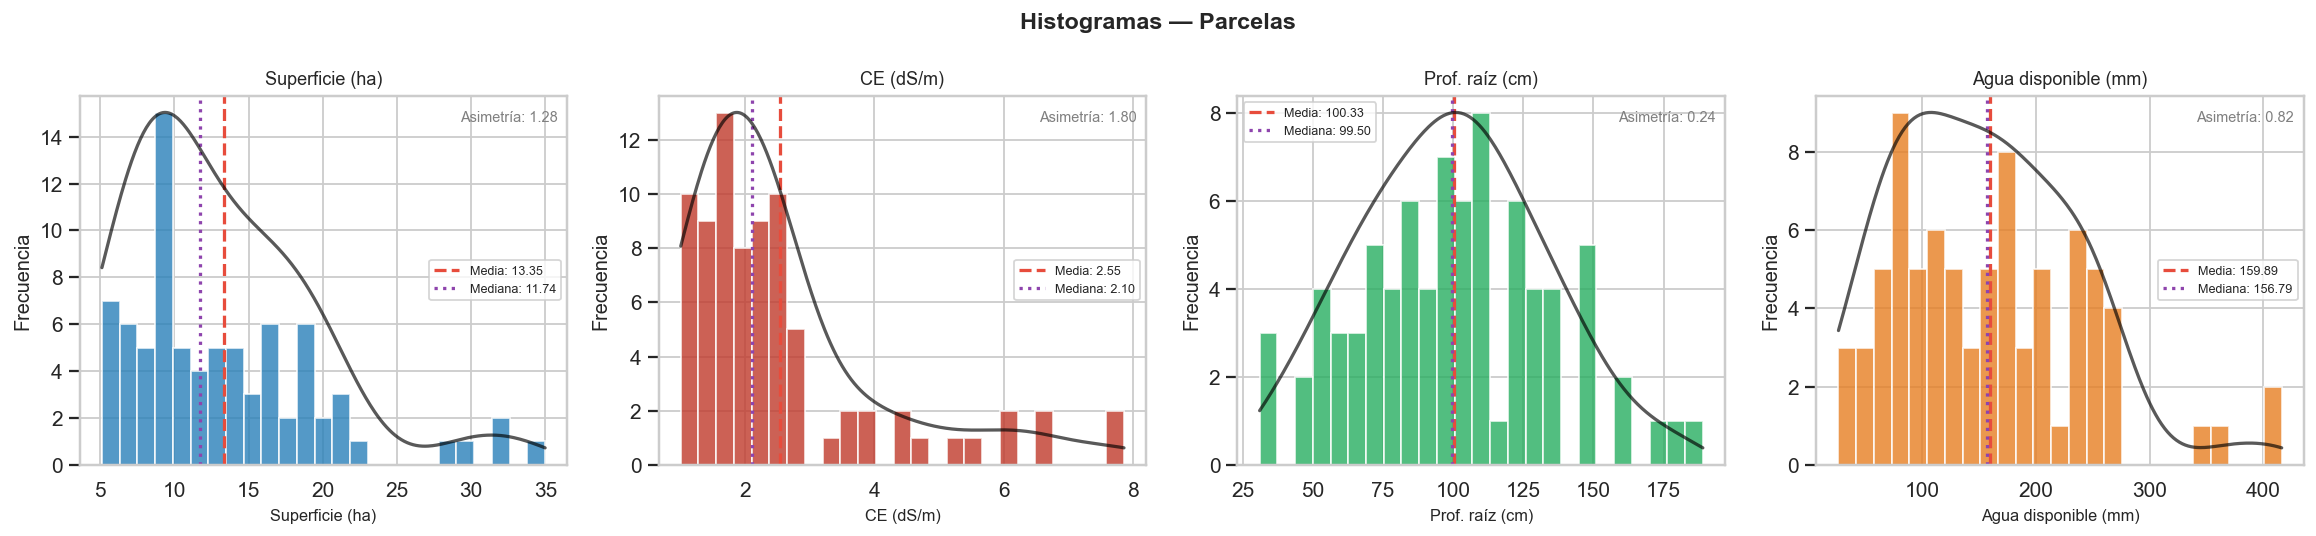

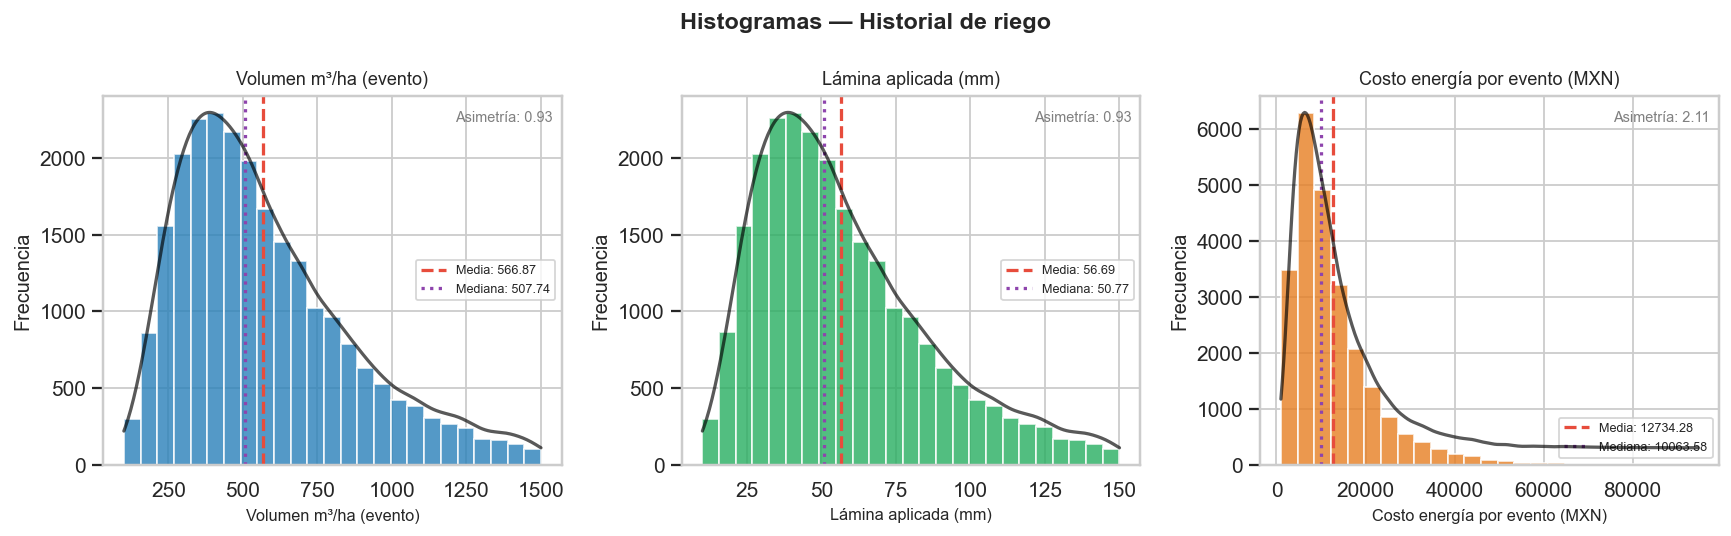

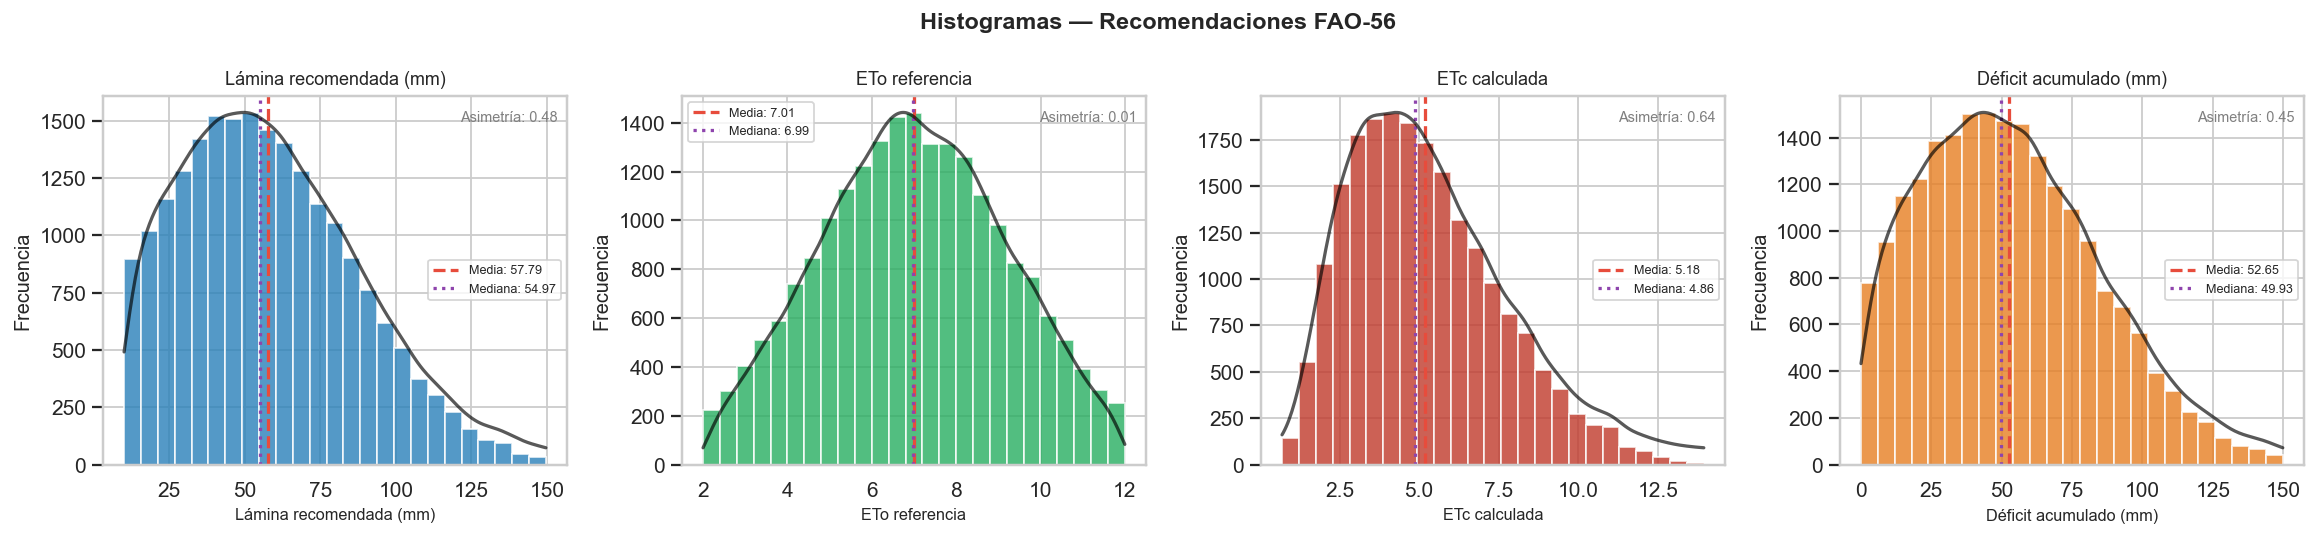

In [19]:
from scipy.stats import gaussian_kde

hist_groups = {
    'Parcelas': {
        'df': parcelas,
        'cols':   ['area_ha', 'conductividad_electrica',
                   'profundidad_raiz_cm', 'agua_disponible_mm'],
        'labels': ['Superficie (ha)', 'CE (dS/m)',
                   'Prof. raíz (cm)', 'Agua disponible (mm)'],
        'colors': [AZUL, ROJO, VERDE, NARANJA],
    },
    'Historial de riego': {
        'df': historial,
        'cols':   ['volumen_m3_ha', 'lamina_mm', 'costo_energia_mxn'],
        'labels': ['Volumen m³/ha (evento)', 'Lámina aplicada (mm)',
                   'Costo energía por evento (MXN)'],
        'colors': [AZUL, VERDE, NARANJA],
    },
    'Recomendaciones FAO-56': {
        'df': recomend,
        'cols':   ['lamina_recomendada_mm', 'eto_referencia',
                   'etc_calculada', 'deficit_acumulado_mm'],
        'labels': ['Lámina recomendada (mm)', 'ETo referencia',
                   'ETc calculada', 'Déficit acumulado (mm)'],
        'colors': [AZUL, VERDE, ROJO, NARANJA],
    },
}

for grupo, cfg in hist_groups.items():
    ncols = len(cfg['cols'])
    fig, axes = plt.subplots(1, ncols, figsize=(4.5 * ncols, 4.2))
    if ncols == 1:
        axes = [axes]
    fig.suptitle(f'Histogramas — {grupo}', fontsize=13, fontweight='bold')

    for ax, col, lbl, color in zip(axes, cfg['cols'], cfg['labels'], cfg['colors']):
        s = cfg['df'][col].dropna()
        ax.hist(s, bins=25, color=color, edgecolor='white', alpha=0.80)
        xs = np.linspace(s.min(), s.max(), 300)
        kde = gaussian_kde(s)
        ax_r = ax.twinx()
        ax_r.plot(xs, kde(xs), color='black', lw=1.8, alpha=0.65)
        ax_r.set_yticks([])
        ax.axvline(s.mean(),   color='#E74C3C', lw=1.8, linestyle='--',
                   label=f'Media: {s.mean():.2f}')
        ax.axvline(s.median(), color='#8E44AD', lw=1.8, linestyle=':',
                   label=f'Mediana: {s.median():.2f}')
        ax.set_title(lbl, fontsize=10)
        ax.set_xlabel(lbl, fontsize=9)
        ax.set_ylabel('Frecuencia')
        ax.legend(fontsize=7)
        ax.text(0.98, 0.96, f'Asimetría: {s.skew():.2f}',
                transform=ax.transAxes, ha='right', va='top',
                fontsize=8, color='gray')

    plt.tight_layout()
    plt.show()
    print()


---
## 9 · Heatmaps — Correlaciones y Patrones Temporales

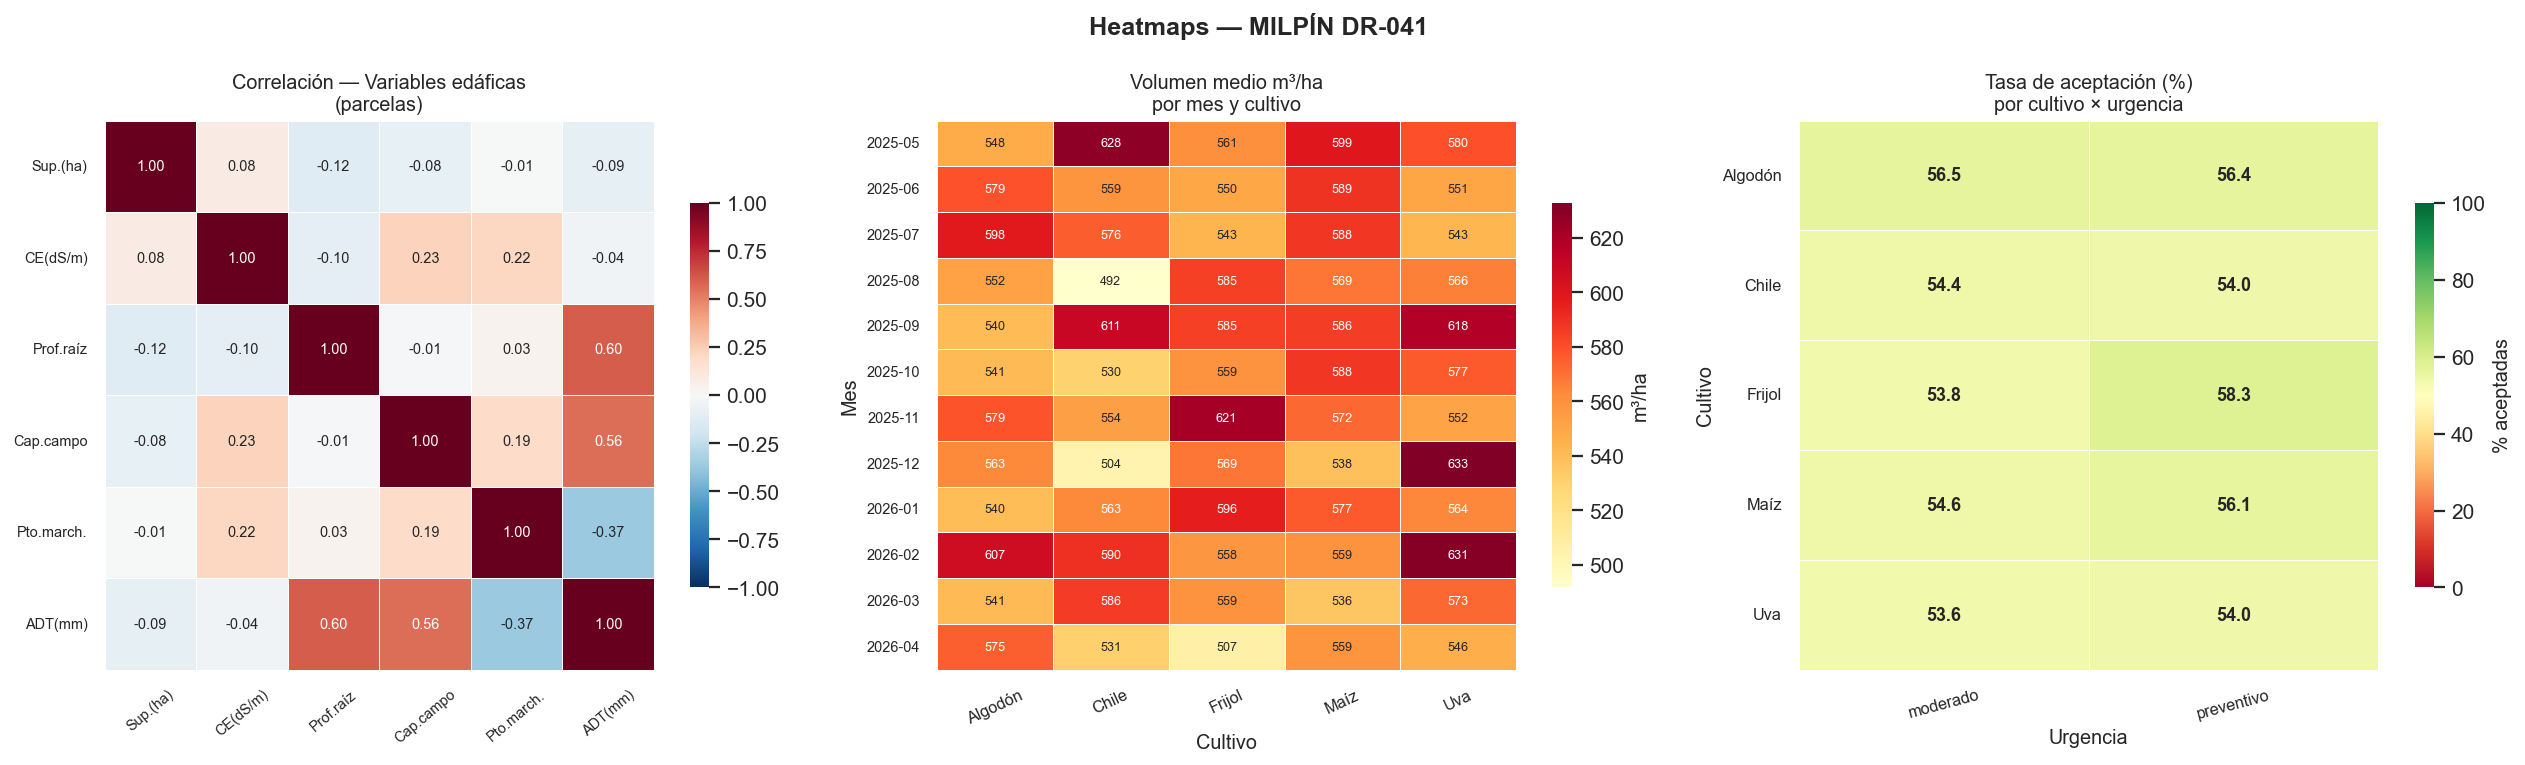

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Heatmaps — MILPÍN DR-041', fontsize=14, fontweight='bold')

# (a) Correlación variables edáficas de parcelas
ax1 = axes[0]
num_cols_parc = ['area_ha', 'conductividad_electrica',
                 'profundidad_raiz_cm', 'capacidad_campo',
                 'punto_marchitez', 'agua_disponible_mm']
corr_parc = parcelas[num_cols_parc].corr()
corr_labels_p = ['Sup.(ha)', 'CE(dS/m)', 'Prof.raíz',
                 'Cap.campo', 'Pto.march.', 'ADT(mm)']
sns.heatmap(corr_parc, ax=ax1, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            xticklabels=corr_labels_p, yticklabels=corr_labels_p,
            annot_kws={'size': 8}, square=True,
            cbar_kws={'shrink': 0.7})
ax1.set_title('Correlación — Variables edáficas\n(parcelas)', fontsize=11)
ax1.tick_params(axis='x', rotation=40, labelsize=8)
ax1.tick_params(axis='y', rotation=0,  labelsize=8)

# (b) Volumen mensual por cultivo
ax2 = axes[1]
hist_m = historial.merge(parcelas[['id_parcela', 'cultivo']],
                         on='id_parcela', how='left')
hist_m['mes_str'] = hist_m['fecha_riego'].dt.strftime('%Y-%m')
pivot_vol = (hist_m.groupby(['mes_str', 'cultivo'])['volumen_m3_ha']
             .mean().unstack(fill_value=0))
if len(pivot_vol) > 12:
    pivot_vol = pivot_vol.tail(12)
sns.heatmap(pivot_vol, ax=ax2, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.4, annot_kws={'size': 7},
            cbar_kws={'shrink': 0.7, 'label': 'm³/ha'})
ax2.set_title('Volumen medio m³/ha\npor mes y cultivo', fontsize=11)
ax2.set_xlabel('Cultivo'); ax2.set_ylabel('Mes')
ax2.tick_params(axis='x', rotation=25, labelsize=9)
ax2.tick_params(axis='y', rotation=0,  labelsize=8)

# (c) Tasa de aceptación por cultivo × urgencia
ax3 = axes[2]
pivot_acept = (recomend.groupby(['cultivo', 'nivel_urgencia'])['aceptada']
               .apply(lambda x: round((x == 'aceptada').mean() * 100, 1))
               .unstack(fill_value=0))
urg_order = [c for c in ['crítico', 'moderado', 'preventivo']
             if c in pivot_acept.columns]
pivot_acept = pivot_acept[urg_order]
sns.heatmap(pivot_acept, ax=ax3, cmap='RdYlGn', annot=True, fmt='.1f',
            vmin=0, vmax=100, linewidths=0.5,
            annot_kws={'size': 10, 'weight': 'bold'},
            cbar_kws={'shrink': 0.7, 'label': '% aceptadas'})
ax3.set_title('Tasa de aceptación (%)\npor cultivo × urgencia', fontsize=11)
ax3.set_xlabel('Urgencia'); ax3.set_ylabel('Cultivo')
ax3.tick_params(axis='x', rotation=15, labelsize=9)
ax3.tick_params(axis='y', rotation=0,  labelsize=9)

plt.tight_layout()
plt.show()


---
## 10 · Ingeniería de Características — Dataset para ML

Se construye un DataFrame a nivel **parcela × ciclo** con features agregadas
de los cuatro datasets, listo para modelos supervisados.

| Target | Tipo | Unidad |
|---|---|---|
| `vol_m3_ha_ciclo` | Regresión | m³/ha por ciclo |
| `meta_alcanzada` | Clasificación binaria | ≤ 6,000 m³/ha/ciclo |

**Cambio clave vs versión anterior:** la granularidad ahora es parcela×ciclo
(~800 filas) en vez de parcela (~80 filas), lo que permite:
- Target balanceado (~45% clase 1)
- Suficientes observaciones para entrenar modelos
- Comparación directa contra baseline 8,000 m³/ha/ciclo


In [21]:
# ══════════════════════════════════════════════════════════════════════════
# FEATURE ENGINEERING — Nivel parcela × ciclo
# ══════════════════════════════════════════════════════════════════════════

# ── Bloque 1: base desde KPI (ya tiene parcela × ciclo) ─────────────────
feat = kpi[[
    'id_parcela', 'ciclo_agricola',
    'eventos_riego', 'vol_m3_ha_ciclo', 'vol_m3_ha_media',
    'lamina_media_mm', 'costo_ciclo_mxn'
]].copy()

# ── Bloque 2: atributos estáticos de parcela ────────────────────────────
parc_cols = parcelas[[
    'id_parcela', 'cultivo', 'area_ha', 'tipo_suelo', 'sistema_riego',
    'conductividad_electrica', 'profundidad_raiz_cm',
    'capacidad_campo', 'punto_marchitez', 'agua_disponible_mm'
]].copy()

parc_cols['stress_salino'] = (parc_cols['conductividad_electrica'] > 4).astype(int)
parc_cols['stress_hidrico'] = (
    parc_cols['agua_disponible_mm'] < parc_cols['agua_disponible_mm'].quantile(0.25)
).astype(int)
parc_cols['stress_doble'] = (
    parc_cols['stress_salino'] & parc_cols['stress_hidrico']
).astype(int)
parc_cols['cap_almacen_relativa'] = (
    (parc_cols['capacidad_campo'] - parc_cols['punto_marchitez'])
    / parc_cols['capacidad_campo']
).round(4)

eff_map = {'goteo': 0.90, 'aspersion': 0.75, 'microaspersion': 0.80, 'gravedad': 0.55}
parc_cols['eficiencia_riego'] = parc_cols['sistema_riego'].map(eff_map).fillna(0.65)

feat = feat.merge(parc_cols, on='id_parcela', how='left')

# ── Bloque 3: variabilidad intra-ciclo del riego ────────────────────────
h_var = (
    historial.groupby(['id_parcela', 'ciclo_agricola']).agg(
        vol_m3_ha_std  = ('volumen_m3_ha', 'std'),
        lamina_cv      = ('lamina_mm',
                          lambda x: x.std() / x.mean() if x.mean() > 0 else 0),
    ).reset_index()
)
h_var['vol_m3_ha_std'] = h_var['vol_m3_ha_std'].fillna(0)
feat = feat.merge(h_var, on=['id_parcela', 'ciclo_agricola'], how='left')

# ── Bloque 4: recomendaciones (agregadas por parcela, no por ciclo,
#    porque recomendaciones no tienen ciclo_agricola) ─────────────────────
r_feats = (
    recomend.groupby('id_parcela').agg(
        n_recomendaciones   = ('id_recomendacion',     'count'),
        tasa_aceptacion     = ('aceptada',
                               lambda x: (x == 'aceptada').mean()),
        tasa_ignorada       = ('aceptada',
                               lambda x: (x == 'ignorada').mean()),
        eto_media           = ('eto_referencia',       'mean'),
        etc_media           = ('etc_calculada',        'mean'),
        deficit_acum_medio  = ('deficit_acumulado_mm', 'mean'),
        lamina_rec_media_mm = ('lamina_recomendada_mm','mean'),
        pct_critico         = ('nivel_urgencia',
                               lambda x: (x == 'crítico').mean()),
        pct_moderado        = ('nivel_urgencia',
                               lambda x: (x == 'moderado').mean()),
    ).reset_index()
)
r_feats['ratio_etc_eto'] = (
    r_feats['etc_media'] / r_feats['eto_media'].replace(0, np.nan)
).round(4)
feat = feat.merge(r_feats, on='id_parcela', how='left')

# ── Bloque 5: costos económicos por ciclo ────────────────────────────────
c_feats = (
    costos.groupby(['id_parcela', 'ciclo_agricola']).agg(
        roi_ciclo            = ('roi_pct',                'mean'),
        margen_ciclo_mxn     = ('margen_contribucion_mxn','sum'),
        ingreso_ciclo_mxn    = ('ingreso_estimado_mxn',   'sum'),
    ).reset_index()
)
feat = feat.merge(c_feats, on=['id_parcela', 'ciclo_agricola'], how='left')

# ── Bloque 6: parámetros FAO-56 del catálogo ────────────────────────────
cult_join = cult[['nombre_comun', 'kc_ponderado', 'ky_total',
                  'ciclo_total_dias']].rename(columns={'nombre_comun': 'cultivo'})
feat = feat.merge(cult_join, on='cultivo', how='left')

# ── Bloque 7: variables objetivo ─────────────────────────────────────────
feat['meta_alcanzada']       = (feat['vol_m3_ha_ciclo'] <= 6000).astype(int)
feat['ahorro_potencial_m3']  = (8000 - feat['vol_m3_ha_ciclo']).clip(lower=0)
feat['ahorro_potencial_mxn'] = feat['ahorro_potencial_m3'] * 1.68

# ── Bloque 8: encoding de categóricas ────────────────────────────────────
feat_encoded = pd.get_dummies(
    feat, columns=['cultivo', 'tipo_suelo', 'sistema_riego'],
    prefix=['cult', 'suelo', 'riego'], drop_first=False, dtype=int
)

print(f'✓ Dataset ML base:    {feat.shape[0]} filas × {feat.shape[1]} columnas')
print(f'✓ Dataset codificado: {feat_encoded.shape[0]} filas × {feat_encoded.shape[1]} columnas')
print()
print('▶ Balance target (meta_alcanzada):')
print(feat['meta_alcanzada']
      .value_counts(normalize=True)
      .rename({0: 'No alcanzada (0)', 1: 'Alcanzada (1)'})
      .map('{:.1%}'.format))
print()
nulls = feat.isnull().sum()
nulls_pos = nulls[nulls > 0]
if len(nulls_pos):
    print('▶ Nulos en dataset ML:')
    print(nulls_pos.to_string())
else:
    print('▶ Nulos en dataset ML: ninguno')


---
## 11 · DataFrame ML — Vista del Dataset Construido

In [22]:
# ── (a) Muestra estilizada ──────────────────────────────────────────────────
cols_show = [
    'id_parcela', 'ciclo_agricola', 'cultivo', 'sistema_riego',
    'area_ha', 'conductividad_electrica', 'agua_disponible_mm',
    'stress_salino', 'eficiencia_riego',
    'eventos_riego', 'vol_m3_ha_ciclo',
    'tasa_aceptacion', 'pct_critico',
    'kc_ponderado', 'ky_total',
    'meta_alcanzada', 'ahorro_potencial_mxn'
]
col_alias = [
    'ID Parcela', 'Ciclo', 'Cultivo', 'Sist. riego',
    'Área (ha)', 'CE (dS/m)', 'ADT (mm)',
    'Estrés sal.', 'Efic. riego',
    'N° eventos', 'Vol m³/ha/ciclo',
    'Tasa acept.', '% Crítico',
    'Kc pond.', 'Ky total',
    'Meta alcanzada', 'Ahorro pot. (MXN)'
]

muestra = feat[cols_show].head(15).copy().reset_index(drop=True)
muestra.columns = col_alias

def _hl_target(v):
    if v == 1:
        return 'background-color:#D5F5E3;color:#1E8449;font-weight:bold'
    return 'background-color:#FADBD8;color:#C0392B;font-weight:bold'

def _hl_stress(v):
    return 'background-color:#FADBD8;font-weight:bold' if v == 1 else ''

display(
    muestra.style
    .set_caption('🤖 Dataset ML — Primeras 15 filas (parcela × ciclo)')
    .applymap(_hl_target, subset=['Meta alcanzada'])
    .applymap(_hl_stress, subset=['Estrés sal.'])
    .background_gradient(subset=['Vol m³/ha/ciclo'], cmap='RdYlGn_r')
    .background_gradient(subset=['Ahorro pot. (MXN)'], cmap='Greens')
    .format({
        'Área (ha)':       '{:.1f}',
        'CE (dS/m)':       '{:.2f}',
        'ADT (mm)':        '{:.1f}',
        'Efic. riego':     '{:.2f}',
        'Vol m³/ha/ciclo': '{:,.0f}',
        'Tasa acept.':     '{:.0%}',
        '% Crítico':       '{:.0%}',
        'Kc pond.':        '{:.3f}',
        'Ky total':        '{:.2f}',
        'Ahorro pot. (MXN)': '${:,.0f}',
    })
    .set_properties(**{'text-align': 'center', 'font-size': '10px'})
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '14px'), ('font-weight', 'bold')]}])
    .hide(axis='index')
)

# ── (b) Estadísticas descriptivas ───────────────────────────────────────────
num_cols_desc = [
    'area_ha', 'conductividad_electrica', 'agua_disponible_mm',
    'eficiencia_riego', 'eventos_riego', 'vol_m3_ha_ciclo',
    'tasa_aceptacion', 'pct_critico',
    'kc_ponderado', 'ky_total',
    'meta_alcanzada', 'ahorro_potencial_mxn'
]
num_cols_desc = [c for c in num_cols_desc if c in feat.columns]
desc_ml = feat[num_cols_desc].describe().T

display(
    desc_ml.style
    .set_caption('📊 Estadísticas descriptivas — Dataset ML (parcela × ciclo)')
    .background_gradient(subset=['mean'], cmap='Blues')
    .background_gradient(subset=['std'],  cmap='Oranges')
    .format('{:.3f}')
    .format('{:.0f}', subset=['count'])
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '14px'), ('font-weight', 'bold')]}])
)

# ── (c) Heatmap de correlación entre features ML y el target ────────────────
num_feats_ml = [
    'area_ha', 'conductividad_electrica', 'agua_disponible_mm',
    'eficiencia_riego', 'cap_almacen_relativa',
    'eventos_riego', 'lamina_media_mm', 'lamina_cv',
    'tasa_aceptacion', 'deficit_acum_medio', 'pct_critico',
    'kc_ponderado', 'ky_total',
    'stress_salino', 'stress_doble',
    'vol_m3_ha_ciclo'
]
num_feats_ml = [c for c in num_feats_ml if c in feat.columns]
corr_ml = feat[num_feats_ml].corr()

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr_ml, ax=ax, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, linewidths=0.3,
    annot_kws={'size': 7},
    xticklabels=[c.replace('_', '\n') for c in corr_ml.columns],
    yticklabels=[c.replace('_', ' ') for c in corr_ml.index],
    square=True, cbar_kws={'shrink': 0.6}
)
ax.set_title(
    'Matriz de correlación — Features ML\n'
    '(última fila/columna = vol_m3_ha_ciclo)',
    fontsize=12, fontweight='bold'
)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
plt.show()

# ── (d) Ranking de correlación con el target ─────────────────────────────────
target_corr = (
    corr_ml['vol_m3_ha_ciclo']
    .drop('vol_m3_ha_ciclo')
    .rename('corr')
    .reset_index()
    .rename(columns={'index': 'Feature'})
)
target_corr['|corr|'] = target_corr['corr'].abs()
target_corr['Dir.']   = target_corr['corr'].apply(
    lambda v: '+ (directa)' if v >= 0 else '− (inversa)'
)
target_corr = target_corr.sort_values('|corr|', ascending=False).reset_index(drop=True)
target_corr.columns = ['Feature', 'Correlación', '|Correlación|', 'Dirección']

display(
    target_corr.style
    .set_caption('🎯 Features por correlación absoluta con vol_m3_ha_ciclo')
    .background_gradient(subset=['|Correlación|'], cmap='Blues')
    .bar(subset=['Correlación'], color=[VERDE, ROJO], align='zero', vmin=-1, vmax=1)
    .format({'Correlación': '{:+.3f}', '|Correlación|': '{:.3f}'})
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '13px'), ('font-weight', 'bold')]}])
    .hide(axis='index')
)
